In [1]:
import numpy as np
import scanpy as sc
import anndata
import openTSNE
from openTSNE.initialization import rescale as rescale_pca
from sklearn.decomposition import PCA
sc.settings.verbosity = 2
from readcount_tools import get_tag, scanpy_preproc_baseline, readcount_pipeline, umi_pipeline

In [2]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from readcount_tools import PAPER_CONTEXT, PAGEWIDTH_IN, POINTSIZE_HIGHLIGHT,POINTSIZE_SMALL,SMALL_SIZE,MEDIUM_SIZE,BIGGER_SIZE,LINEWIDTH,POINTSIZE,TICKLENGTH,LEGEND_FONTSIZE,SPINEWIDTH,LETTER_LOC_X,LETTER_LOC_Y
import matplotlib as mpl

In [5]:
n_hvgs=3000
n_comps=1000

### Load simulated data

In [6]:
%%time
#simulation 1
adata_sim = anndata.read_h5ad('data/tasic/simulations/adata_sim_qumi_census_tpm.h5ad')
#simulation 2
adata_sim_only_marker_genes_DE = anndata.read_h5ad('data/tasic/simulations/adata_sim_only_marker_genes_DE_qumi_census_tpm.h5ad')

tcmalloc: large alloc 5364908032 bytes == 0x1458f6000 @ 
tcmalloc: large alloc 5364908032 bytes == 0x431480000 @ 


CPU times: user 2.6 s, sys: 16 s, total: 18.6 s
Wall time: 54.9 s


In [7]:
def clean_layers(ad,keep=None):
    for layer in list(ad.layers.keys()):
        if layer==keep:
            ad.X = ad.layers[layer]
        else:
            del ad.layers[layer]
    return ad

In [8]:
%%time
adata_sim1_readcounts = clean_layers(adata_sim_only_marker_genes_DE.copy(),keep='readcounts')
adata_sim1_qumis = clean_layers(adata_sim_only_marker_genes_DE.copy(),keep='qumis')
adata_sim1_census = clean_layers(adata_sim_only_marker_genes_DE.copy(),keep='census')

adata_sim2_readcounts = clean_layers(adata_sim.copy(),keep='readcounts')
adata_sim2_qumis = clean_layers(adata_sim.copy(),keep='qumis')
adata_sim2_census = clean_layers(adata_sim.copy(),keep='census')

tcmalloc: large alloc 5364908032 bytes == 0x6e4a5a000 @ 
tcmalloc: large alloc 5364908032 bytes == 0x6e4a5a000 @ 
tcmalloc: large alloc 5364908032 bytes == 0x6e4a5a000 @ 
tcmalloc: large alloc 5364908032 bytes == 0x6e4a5a000 @ 
tcmalloc: large alloc 5364908032 bytes == 0x6e4a5a000 @ 
tcmalloc: large alloc 5364908032 bytes == 0x6e4a5a000 @ 


CPU times: user 11 s, sys: 5.17 s, total: 16.2 s
Wall time: 16.2 s


In [9]:
%%time
for ad in [adata_sim1_readcounts,adata_sim1_qumis,adata_sim1_census,
           adata_sim2_readcounts,adata_sim2_qumis,adata_sim2_census]:
    print(f'shape before {ad.shape}')
    sc.pp.filter_genes(ad,min_cells=5)
    print(f'shape after {ad.shape}')
    print('')

shape before (23822, 28151)
filtered out 6830 genes that are detected in less than 5 cells
shape after (23822, 21321)

shape before (23822, 28151)
filtered out 6830 genes that are detected in less than 5 cells
shape after (23822, 21321)

shape before (23822, 28151)
filtered out 6830 genes that are detected in less than 5 cells
shape after (23822, 21321)

shape before (23822, 28151)
filtered out 6754 genes that are detected in less than 5 cells
shape after (23822, 21397)

shape before (23822, 28151)
filtered out 6754 genes that are detected in less than 5 cells
shape after (23822, 21397)

shape before (23822, 28151)
filtered out 6754 genes that are detected in less than 5 cells
shape after (23822, 21397)

CPU times: user 13.4 s, sys: 1.74 s, total: 15.1 s
Wall time: 15.1 s


### Run Scanpy Default pipeline on readcounts

In [10]:
%%time
adata_sim1_scanpy,hvg_sim1_scanpy = scanpy_preproc_baseline(adata_sim1_readcounts,
                                                                           n_hvgs = n_hvgs,
                                                                           n_comps = n_comps,
                                                                           return_full_hvg_results=True)
adata_sim2_scanpy,hvg_sim2_scanpy = scanpy_preproc_baseline(adata_sim2_readcounts,
                                                      n_hvgs = n_hvgs,
                                                      n_comps = n_comps,
                                                      return_full_hvg_results=True)

normalizing counts per cell
    finished (0:00:01)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:02)
normalizing counts per cell
    finished (0:00:00)
--------------------------------------------------------------------------------
TSNE(n_jobs=38, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 6.92 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.24 seconds
===> Running optimization with exaggeration=12.00, lr=1985.17 for 250 iterations...
Iteration   50, KL divergence 5.4945, 50 iterations in 1.1888 sec
Iteration  100, KL divergence 4.2607, 50 iterations in 1.1728 sec
Iteration  150, KL divergence 3.8881, 50 iterations in 1.1829 sec
Iteration  200, KL divergence 3.7052, 50 iterations in 1.2215 sec
Iteration  250, KL divergence 3.5822

### Run compound residuals pipeline on readcounts

In [11]:
alpha=50
theta_umi=100

In [12]:
%%time
adata_sim1_CPRs_hvg,adata_sim1_CPRs = readcount_pipeline(adata_sim1_readcounts,
                                                         alpha=alpha,
                                                         theta=theta_umi,
                                                         n_hvgs = n_hvgs,
                                                         n_comps = n_comps,
                                                         return_full_hvg_results=True)
adata_sim2_CPRs_hvg,adata_sim2_CPRs = readcount_pipeline(adata_sim2_readcounts,
                                    alpha=alpha,
                                    theta=theta_umi,
                                    n_hvgs = n_hvgs,
                                    n_comps = n_comps,
                                    return_full_hvg_results=True)

pr_theta100_alpha50.0


tcmalloc: large alloc 4077756416 bytes == 0xd4df16000 @ 
tcmalloc: large alloc 4077756416 bytes == 0xe40ff0000 @ 
tcmalloc: large alloc 4077756416 bytes == 0xf348ca000 @ 
tcmalloc: large alloc 4077756416 bytes == 0xe40ff0000 @ 


pr_theta100_alpha50.0_afterHVG
--------------------------------------------------------------------------------
TSNE(n_jobs=38, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 6.45 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.20 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.95 seconds
===> Running optimization with exaggeration=12.00, lr=1985.17 for 250 iterations...
Iteration   50, KL divergence 5.5685, 50 iterations in 1.2504 sec
Iteration  100, KL divergence 4.2781, 50 iterations in 1.1746 sec
Iteration  150, KL divergence 3.8515, 50 iterations in 1.1772 sec
Iteration  200, KL divergence 3.6415, 50 iterations in 1.1811 sec
Iteration  250, KL divergence 3.4890, 50 iterations in 1.1621 sec
   --> Time elapsed: 5.95 seconds
===> Running optimization with exagg

### Run UMI pipeline on readcounts

In [26]:
adata_sim1_readcounts_umiproc = clean_layers(adata_sim_only_marker_genes_DE.copy(),keep='readcounts')
adata_sim2_readcounts_umiproc = clean_layers(adata_sim.copy(),keep='readcounts')

umi_pipeline(adata_sim1_readcounts_umiproc,n_comps=n_comps,n_hvgs=n_hvgs)
umi_pipeline(adata_sim2_readcounts_umiproc,n_comps=n_comps,n_hvgs=n_hvgs)

filtered out 6830 genes that are detected in less than 5 cells
extracting highly variable genes
computing analytic Pearson residuals on adata.X
    finished (0:00:02)
computing PCA
    on highly variable genes
    with n_comps=1000
    finished (0:02:26)
--------------------------------------------------------------------------------
TSNE(n_jobs=38, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 8.56 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.25 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.54 seconds
===> Running optimization with exaggeration=12.00, lr=1985.17 for 250 iterations...
Iteration   50, KL divergence 6.8491, 50 iterations in 1.5391 sec
Iteration  100, KL divergence 6.7677, 50 iterations in 1.8515 sec
Iteration  150, KL divergence 6.7267, 50 ite

### Run Scanpy on qUMIs

In [14]:
%%time
adata_sim1_qumis_scanpy,hvg_sim1_qumis_scanpy = scanpy_preproc_baseline(adata_sim1_qumis,
                                                                           n_hvgs = n_hvgs,
                                                                           n_comps = n_comps,
                                                                           return_full_hvg_results=True)
adata_sim2_qumis_scanpy,hvg_sim2_qumis_scanpy = scanpy_preproc_baseline(adata_sim2_qumis,
                                                      n_hvgs = n_hvgs,
                                                      n_comps = n_comps,
                                                      return_full_hvg_results=True)

normalizing counts per cell
    finished (0:00:01)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:02)
normalizing counts per cell
    finished (0:00:00)
--------------------------------------------------------------------------------
TSNE(n_jobs=38, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 6.65 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.26 seconds
===> Running optimization with exaggeration=12.00, lr=1985.17 for 250 iterations...
Iteration   50, KL divergence 6.3207, 50 iterations in 1.3001 sec
Iteration  100, KL divergence 5.1739, 50 iterations in 1.5329 sec
Iteration  150, KL divergence 4.8426, 50 iterations in 1.6556 sec
Iteration  200, KL divergence 4.7444, 50 iterations in 1.4113 sec
Iteration  250, KL divergence 4.6321

### Run Scanpy on Census counts

In [15]:
%%time
adata_sim2_census_scanpy,hvg_sim2_census_scanpy = scanpy_preproc_baseline(adata_sim2_census,
                                                      n_hvgs = n_hvgs,
                                                      n_comps = n_comps,
                                                      return_full_hvg_results=True)
adata_sim1_census_scanpy,hvg_sim1_census_scanpy = scanpy_preproc_baseline(adata_sim1_census,
                                                                           n_hvgs = n_hvgs,
                                                                           n_comps = n_comps,
                                                                           return_full_hvg_results=True)

normalizing counts per cell
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:03)
normalizing counts per cell
    finished (0:00:00)
--------------------------------------------------------------------------------
TSNE(n_jobs=38, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 6.62 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.24 seconds
===> Running optimization with exaggeration=12.00, lr=1985.17 for 250 iterations...
Iteration   50, KL divergence 6.1582, 50 iterations in 1.3371 sec
Iteration  100, KL divergence 4.8798, 50 iterations in 1.4279 sec
Iteration  150, KL divergence 4.5753, 50 iterations in 1.4391 sec
Iteration  200, KL divergence 4.3762, 50 iterations in 1.2270 sec
Iteration  250, KL divergence 4.3234

### Compute kNN Acc on the HVG PCA Space

In [84]:
def knn_acc_loocv(X, y, n_neighbors=10):
    '''returns unbalanced and class-size adjusted kNN accuracy'''
    neigh = NearestNeighbors(n_neighbors=n_neighbors).fit(X)
    knn = neigh.kneighbors(return_distance=False)
    yhat = mode(y[knn], axis=1).mode.flatten()
    return np.mean(yhat == y), balanced_accuracy_score(y_pred=yhat,y_true=y)

In [85]:
%%time
CPR_acc,CPR_acc_bal = knn_acc_loocv(X=adata_sim2_CPRs_hvg.obsm['pca1000'],
                                    y=adata_sim2_CPRs_hvg.obs['clusters'].values)

qumis_acc,qumis_acc_bal = knn_acc_loocv(X=adata_sim2_qumis_scanpy.obsm['pca1000'],
                                        y=adata_sim2_qumis_scanpy.obs['clusters'].values)

census_acc,census_acc_bal = knn_acc_loocv(X=adata_sim2_census_scanpy.obsm['pca1000'],
                                        y=adata_sim2_census_scanpy.obs['clusters'].values)

scanpy_acc,scanpy_acc_bal = knn_acc_loocv(X=adata_sim2_scanpy.obsm['pca1000'],
                                          y=adata_sim2_scanpy.obs['clusters'].values)

umiproc_acc,umiproc_acc_bal = knn_acc_loocv(X=adata_sim2_readcounts_umiproc.obsm['X_pca'],
                                          y=adata_sim2_readcounts_umiproc.obs['clusters'].values)

CPU times: user 12min 22s, sys: 9min 7s, total: 21min 30s
Wall time: 1min 3s


In [258]:
print('Residuals',np.round(CPR_acc*100,decimals=1),np.round(CPR_acc_bal*100,decimals=1),'\n',
      'UMI Residuals',np.round(umiproc_acc*100,decimals=1),np.round(umiproc_acc_bal*100,decimals=1),'\n',
      'Scanpy',np.round(scanpy_acc*100,decimals=1),np.round(scanpy_acc_bal*100,decimals=1))

print('qUMI+scanpy',np.round(qumis_acc*100,decimals=1), np.round(qumis_acc_bal*100,decimals=1),'\n',
      'Census+scanpy',np.round(census_acc*100,decimals=1),np.round(census_acc_bal*100,decimals=1))

Residuals 98.8 97.3 
 UMI Residuals 57.4 64.0 
 Scanpy 98.7 97.2
qUMI+scanpy 70.4 70.0 
 Census+scanpy 79.1 72.9


### Plotting

In [300]:
def mean_hvgcriterion_plot(ax,mean,criterion,label,icol):
    
    criterion_marker = criterion[marker_idx.values]
    ax.scatter(mean,criterion,lw=0,s=POINTSIZE_SMALL,rasterized=True,clip_on=False)
    ax.scatter(mean[marker_idx.values],criterion_marker,lw=1,s=POINTSIZE_HIGHLIGHT,c='tab:red',rasterized=True,clip_on=False)
    
    ax.set_xscale('log')
    
    
    if 'Scanpy' in label:
        ax.set_yscale('linear')
        ax.set_yticks([])
    else:
        ax.set_yscale('log')
        ax.set_yticks([])
        
    
    ax.minorticks_off()
    ax.set_xticks([])
    
    #compute percentage of markers among the top [n_markers] HVGs
    n_markers = len(criterion_marker)
    topn_criterion = criterion[np.argsort(-criterion)[n_markers]]
    marker_in_topn = criterion_marker > topn_criterion
    marker_recovered = int(np.round(sum(marker_in_topn)/n_markers,decimals=2)*100)
    if icol==0:
        performancelabeltext='\nmarker\nrecovery'
        ax.set_xlabel('Mean expression')
    else:
        performancelabeltext=''
    ax.text(0.05,1.025,f'{marker_recovered}%{performancelabeltext}',fontsize=LEGEND_FONTSIZE,transform=ax.transAxes,va='top')
        

    
    ax.set_title(label)
    sns.despine()

In [301]:
ncols = 5
nrows = 2
nrows_grid = 9
nrows_tsne=5
fraction_hight_tsne = nrows_tsne/nrows_grid
panelsize_tsne_in = PAGEWIDTH_IN/ncols
figheight_in = panelsize_tsne_in*(1/fraction_hight_tsne)*1.1

In [302]:
(PAGEWIDTH_IN,figheight_in)

(6.25, 2.475)

In [303]:
mean_raw = adata_sim1_CPRs.var.means
mean_census = adata_sim1_census.X.mean(axis=0).A.flatten()
mean_qumi = adata_sim1_qumis.X.mean(axis=0).A.flatten()

criterion_cprs = adata_sim1_CPRs.var['pr_theta100_alpha50.0_var']
criterion_scanpy = hvg_sim1_scanpy['dispersions_norm']
criterion_qumi = hvg_sim1_qumis_scanpy['dispersions_norm']
criterion_census = hvg_sim1_census_scanpy['dispersions_norm']
criterion_umiproc = adata_sim1_readcounts_umiproc.var['residual_variances']
marker_idx = adata_sim1_readcounts.var.marker_idx

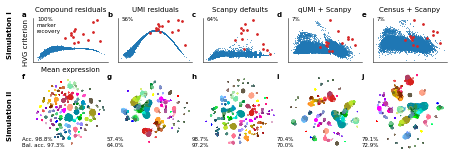

In [304]:
path='figures/main_tasic_simulation_census_qumis.pdf'

with mpl.rc_context(PAPER_CONTEXT):

    fig = plt.figure(figsize=(PAGEWIDTH_IN,figheight_in))


    ncols_grid = ncols
    axes_resvar1 = [plt.subplot2grid(shape=(nrows_grid,ncols_grid), loc=(0, col),       colspan=1,rowspan=3) for col in range(ncols_grid)]
    axes_tsne = [plt.subplot2grid(shape=(nrows_grid,ncols_grid), loc=(3, col),          colspan=1,rowspan=nrows_tsne) for col in range(ncols_grid)]

    
    ##top row: Simulation 1
    for icol,(ax,mean,criterion,label) in enumerate(zip(axes_resvar1,
                              [mean_raw,mean_raw,mean_raw,mean_raw,mean_raw,],      #rawcounts on X axis for all
                              [criterion_cprs,criterion_umiproc,criterion_scanpy,criterion_qumi,criterion_census],
                              ['Compound residuals','UMI residuals','Scanpy defaults','qUMI + Scanpy','Census + Scanpy'])):
        if icol==0:
            ax.set_ylabel('HVG criterion  ',fontsize=MEDIUM_SIZE)#,labelpad=0)
            ax.text(-0.35,0.1,'Simulation I',rotation=90,fontweight='bold',fontsize=MEDIUM_SIZE,transform=ax.transAxes)
            
        mean_hvgcriterion_plot(ax,mean,criterion,label,icol)

    for icol,(ax,ad) in enumerate(zip(axes_tsne,
                                      [adata_sim2_CPRs_hvg,adata_sim2_readcounts_umiproc,adata_sim2_scanpy,adata_sim2_qumis_scanpy,adata_sim2_census_scanpy])):
        
        if icol==0:
            ax.text(-0.35,0.1,'Simulation II',rotation=90,fontweight='bold',fontsize=MEDIUM_SIZE,transform=ax.transAxes)
        ax.scatter(*ad.obsm['tsne'].T,c=ad.obs.clustercolor,s=POINTSIZE,lw=0,rasterized=True)
        ax.set_aspect('equal')
        ax.axis('off')
    
    sns.despine()
    plt.tight_layout()  
    
    
    for icol,(ax,ax_rv,acc,acc_bal) in enumerate(zip(axes_tsne, axes_resvar1,
                                  [CPR_acc,           umiproc_acc,                 scanpy_acc,      qumis_acc,             census_acc],
                                  [CPR_acc_bal,       umiproc_acc_bal,             scanpy_acc_bal,  qumis_acc_bal,         census_acc_bal])):
        if icol==0:
            acc_label='Acc. '
            balacc_label='Bal. acc. '
        else:
            acc_label=''
            balacc_label=''
        ax_rv.text(LETTER_LOC_X+0.15,-1.9,f'{acc_label}{np.round(acc*100,decimals=1)}%\n{balacc_label}{np.round(acc_bal*100,decimals=1)}%',fontsize=LEGEND_FONTSIZE,transform=ax_rv.transAxes)
    
    letters=['a','b','c','d','e',
             'f','g','h','i','j']
    for ax,icol,irow,letter, in zip(np.concatenate((axes_resvar1, axes_resvar1)),
                          np.concatenate((np.arange(ncols), np.arange(ncols))),
                          np.concatenate((np.zeros(ncols).astype(int), np.ones(ncols).astype(int))),
                          letters):
        ax.text(LETTER_LOC_X+0.15,LETTER_LOC_Y+0.08+(-1.4*irow),letter,transform=ax.transAxes,fontweight='bold')          

        
        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(SPINEWIDTH)
    
    fig.savefig(path, dpi=300, format=None, bbox_inches = 'tight', pad_inches = 0)

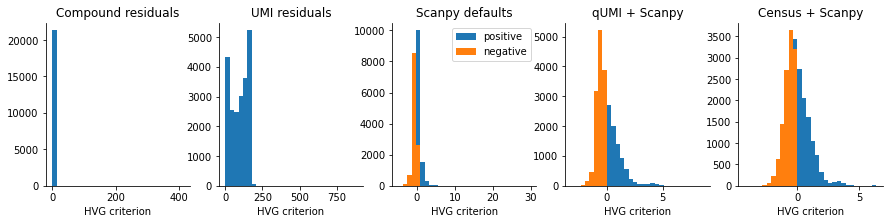

In [305]:
plt.figure(figsize=(15,3))
for i,(c,t) in enumerate(zip([criterion_cprs,criterion_umiproc,criterion_scanpy,criterion_qumi,criterion_census],
                        ['Compound residuals','UMI residuals','Scanpy defaults','qUMI + Scanpy','Census + Scanpy'])):
    plt.subplot(151+i)
    _,bins,_=plt.hist(c,bins=30,label='positive')
    plt.hist(c[c<0],bins=bins,label='negative')
    if i==2:
        plt.legend()
    plt.title(t)
    plt.xlabel('HVG criterion')

    sns.despine()